In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Create Synthetic Dataset

In [2]:
# set the number of rows
n = 80

# generate the data set

# create the categorical variables
# create the constant of 1 virus
virus = ['Influenza_B'] * n

# create the surfaces in the data set by assigning each equaly
surface = ["Stainless_Steel"] * 20 + ["Plastic"] * 20 + ["Granite"] * 20 + ["Glass"] * 20

# create the options for disinfectant
# need to select the two things equaly within each value of surface
disinfectant = []
for i in range(4):
    disinfectant.extend(["Control"] * 10 + ["Disinfectant"] * 10)

# create the application method
application = []
for i in range(8):
    application.extend(["Wipes"] * 5 + ["Spray"] * 5)

# create dataframe containing the categorical variables
df = pd.DataFrame({
    "Virus": virus,
    "Surface": surface,
    "Disinfectant": disinfectant,
    "Application" : application
})

# create continuous variables and add them to the dataframe
# use random seed to ensure replicability
np.random.seed(42)

# create the random values for temperature
df["Temperature_Celsius"] = np.random.uniform(17, 27, 80)
df["Temperature_Celsius"] = df["Temperature_Celsius"].round(2) # add to data frame and round

# function to create the random values for porosity based on surface
def get_porosity(surface):
    if surface == "Stainless_Steel":
        return np.random.uniform(0,0.2) #range determined from avg porosity of stainless steel
    elif surface == "Plastic":
        return 0
    elif surface == "Granite":
        return np.random.uniform(0.05,1.5) # range determined from avg. porosity of granite
    else:
        return 0

df['Porosity'] = df['Surface'].apply(get_porosity) #run function using surface as input
df['Porosity'] = df['Porosity'].round(2) #add to dataframe and round


# create random values for time based on all input variables

# set seed for reproducibility
np.random.seed(42)

# empty list
time_list = []

# loop to create all time values based on inputs
for i, row in df.iterrows():
    if row["Disinfectant"] == "Control":
        # control: 24–48 h in minutes
        if row["Surface"] == "Stainless_Steel":
            time = np.random.randint(1900, 2100)
        elif row["Surface"] == "Plastic":
            time = np.random.randint(2000, 2200)
        elif row["Surface"] == "Granite":
            time = np.random.randint(1800, 2000)
        else:  # glass
            time = np.random.randint(1850, 2050)
    else:
        # disinfectant: 2–10 minutes
        if row["Surface"] == "Stainless_Steel":
            if row["Application"] == "Wipes":
                time = np.random.randint(3, 10)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 8)
            else:
                time = np.random.randint(4, 6)
        elif row["Surface"] == "Plastic":
            if row["Application"] == "Wipes":
                time = np.random.randint(4, 10)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 7)
            else:
                time = np.random.randint(3, 6)
        elif row["Surface"] == "Granite":
            if row["Application"] == "Wipes":
                time = np.random.randint(4, 10)
            elif row["Application"] == "Spray":
                time = np.random.randint(3, 8)
            else:
                time = np.random.randint(5, 7)
        else:  # glass
            if row["Application"] == "Wipes":
                time = np.random.randint(3, 10)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 8)
            else:
                time = np.random.randint(3, 5)

    time_list.append(time)
# assign time values to the dataframe
df["Time"] = time_list

# add new columns for crossover/washout RCT

# create empty lists
application_2_list = []
time_2_list = []

# assign new applications that are opposite of original application
for i, row in df.iterrows():

    # flip application
    if row["Application"] == "Wipes":
        app2 = "Spray"
    else:
        app2 = "Wipes"

    application_2_list.append(app2)

    # create Time_2
    time2 = row["Time"]

    if app2 == "Spray":
        time2 = time2 + 2.0 #ensure slight effect that spray to wipes is better than wipes to spray

    time_2_list.append(time2)

# add new columns to dataframe
df["Application_2"] = application_2_list
df["Time_2"] = time_2_list

# add new columns for withdrawal RCT

# subset data to only use the 'Disinfectant' rows
df_w = df[df["Disinfectant"] == "Disinfectant"].copy()

# assign withdrawal status (50/50 split)
np.random.seed(42)
mask = np.random.rand(len(df_w)) < 0.5
df_w['Withdrawal_Status'] = np.where(mask, 'Continued', 'Withdrawn')

# generate viral load data (T1 = baseline, T2 = after withdrawal period)
df_w['Viral_Load_T1'] = np.random.uniform(5, 15, len(df_w))

def calculate_rebound(row):
    if row['Withdrawal_Status'] == 'Withdrawn':
        # High rebound because disinfectant was stopped
        return row['Viral_Load_T1'] + np.random.uniform(100, 300)
    else:
        # Low rebound because disinfectant continued
        return row['Viral_Load_T1'] + np.random.uniform(0, 20)

df_w['Viral_Load_T2'] = df_w.apply(calculate_rebound, axis=1)

# merge subset data back to original df
# merging creates NaN for original Control group rows
df = df.merge(
    df_w[['Withdrawal_Status', 'Viral_Load_T1', 'Viral_Load_T2']],
    left_index=True,
    right_index=True,
    how='left'
)


# add more rows and create matched pairs for matched pairs RCT

# make a copy of original dataset
df_duplicate = df.copy()

# swap application values
df_duplicate["Application"] = df_duplicate["Application"].map({
    "Wipes": "Spray",
    "Spray": "Wipes"
})

# combine original + duplicate
df = pd.concat([df, df_duplicate], ignore_index=True)

# create Pair_ID of each original row matched with its duplicate
df["Pair_ID"] = np.tile(range(1, (len(df)//2) + 1), 2)




df.head(25)

,Virus,Surface,Disinfectant,Application,Temperature_Celsius,Porosity,Time,Application_2,Time_2,Withdrawal_Status,Viral_Load_T1,Viral_Load_T2,Pair_ID
0,Influenza_B,Stainless_Steel,Control,Wipes,20.75,0.17,2002,Spray,2004.0,NaN,NaN,NaN,1
1,Influenza_B,Stainless_Steel,Control,Wipes,26.51,0.12,2079,Spray,2081.0,NaN,NaN,NaN,2
2,Influenza_B,Stainless_Steel,Control,Wipes,24.32,0.07,1992,Spray,1994.0,NaN,NaN,NaN,3
3,Influenza_B,Stainless_Steel,Control,Wipes,22.99,0.01,1914,Spray,1916.0,NaN,NaN,NaN,4
4,Influenza_B,Stainless_Steel,Control,Wipes,18.56,0.06,2006,Spray,2008.0,NaN,NaN,NaN,5
5,Influenza_B,Stainless_Steel,Control,Spray,18.56,0.07,1971,Wipes,1971.0,NaN,NaN,NaN,6
6,Influenza_B,Stainless_Steel,Control,Spray,17.58,0.15,2088,Wipes,2088.0,NaN,NaN,NaN,7
7,Influenza_B,Stainless_Steel,Control,Spray,25.66,0.13,1920,Wipes,1920.0,NaN,NaN,NaN,8
8,Influenza_B,Stainless_Steel,Control,Spray,23.01,0.18,2002,Wipes,2002.0,NaN,NaN,NaN,9
9,Influenza_B,Stainless_Steel,Control,Spray,24.08,0.09,2021,Wipes,2021.0,NaN,NaN,NaN,10


## Exploratory Data Analysis

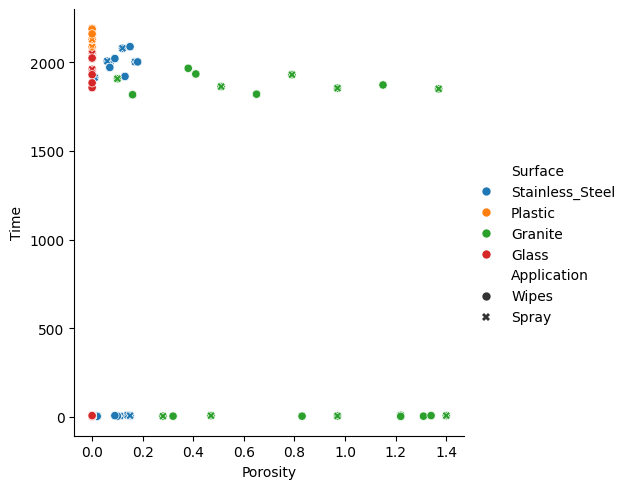

In [3]:
# Scatter plot to visualize relationship between porosiy, surface, application and time
sns.relplot(data=df, x='Porosity', y='Time', hue='Surface', style='Application')
plt.show()

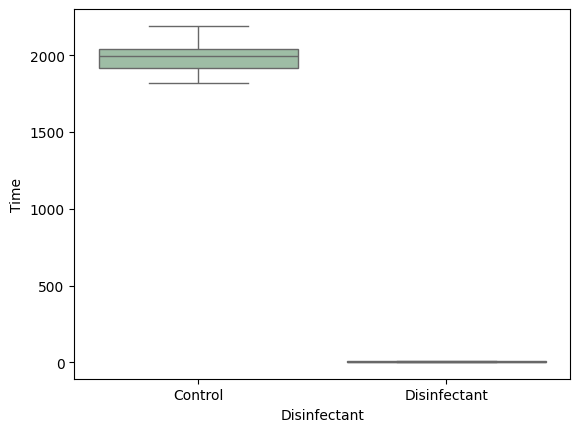

In [4]:
# Box plot to look at different treatments
sns.boxplot(x='Disinfectant', y='Time', data=df,
                 color='#99c2a2')
plt.show()

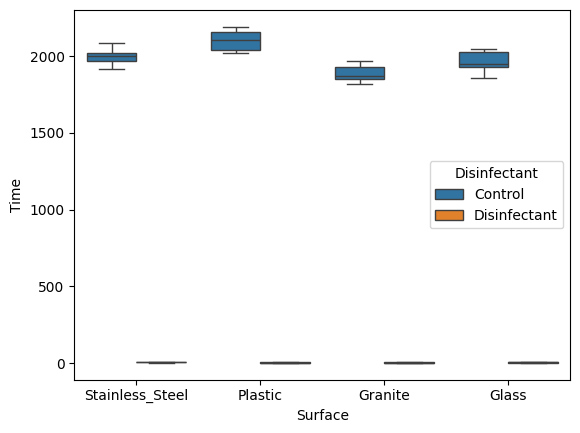

In [5]:
# Box plot to look at different surfaces
sns.boxplot(x='Surface', y='Time', hue= 'Disinfectant', data=df)
plt.show()

In [ ]:
# count plot for categorical?

In [ ]:
# histogram for time?

## Parallel Randomized Control Trial

In [6]:
# Subset data for Parallel RCT
df_parallel = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Temperature_Celsius",
    "Porosity",
    "Time"
]].copy()

### Hypothesis
H0 = There is no difference in the disinfectant abilitiy of a disinfectant applied with wipes or spray  
H1 = There is a difference in the disinfectant abilitiy of a disinfectant applied with wipes or spray

### ANOVA
##### Testing the interaction between Disinfectant and Application Method

In [7]:
#ANOVA 1: Testing the interaction between Disinfectant and Application Method
# This checks if 'Spray' vs 'Wipes' actually changes the 'Time' outcome  differently depending on whether it's a Control or Disinfectant.
model_anova1 = smf.ols("Time ~ C(Disinfectant) * C(Application)", data=df_parallel).fit()
anova_results_1 = anova_lm(model_anova1, typ=2)

print("\nANOVA 1: Disinfectant * Application")
print(anova_results_1)


ANOVA 1: Disinfectant * Application
                                      sum_sq     df             F  \
C(Disinfectant)                 1.571012e+08    1.0  3.133150e+04   
C(Application)                  2.991548e-24    1.0  5.966196e-28   
C(Disinfectant):C(Application)  1.322684e-23    1.0  2.637896e-27   
Residual                        7.822095e+05  156.0           NaN   

                                       PR(>F)  
C(Disinfectant)                 1.034403e-181  
C(Application)                   1.000000e+00  
C(Disinfectant):C(Application)   1.000000e+00  
Residual                                  NaN  


### Power Analysis

In [8]:
# Create groupings by surface
groups = [
    df_parallel[df_parallel["Surface"] == "Glass"]["Time"].dropna(),
    df_parallel[df_parallel["Surface"] == "Granite"]["Time"].dropna(),
    df_parallel[df_parallel["Surface"] == "Stainless_Steel"]["Time"].dropna(),
    df_parallel[df_parallel["Surface"] == "Plastic"]["Time"].dropna(),
]

# Calculate mean of combined data
dataPar = np.concatenate(groups)
dataPar_mean = np.mean(dataPar)

# Calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - dataPar_mean) ** 2
    for group in groups
)

# Calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups
)

# Calculate effect size using Cohen's f
effect_size = np.sqrt(ss_between / ss_within)

# Display effect size result
print(f'Effect size: {effect_size:.2f}')

# Conduct power analysis
power_analysis = FTestAnovaPower()
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    k_groups=4
)

# Display power analysis result
print(f'The sample size required per group is: {sample_size:.0f}')

Effect size: 0.04
The sample size required per group is: 6715


## Factorial Randomized Control Trial

In [9]:
# subset dataset for factorial RCT
df_factorial = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Temperature_Celsius",
    "Porosity",
    "Time"
]].copy()

#df[df["Disinfectant"] == "Disinfectant"].copy()


### Hypothesis
H0 = There is no difference between the disinfectant ability using wipes or spray across different surfaces  
H1 = There is a difference between the disinfectant ability using wipes or spray across different surfaces

### ANOVA
##### Testing the factorial interaction between Disinfectant Application Method and Surface

In [10]:
# two-way factorial ANOVA

# We use 'Time' as the dependent variable to see if disinfectant application effectiveness depends on the specific surface it's applied to.
model = smf.ols('Time ~ C(Disinfectant) + C(Application) + C(Surface) + C(Application):C(Surface)',
            data=df_factorial).fit()

anova_table = anova_lm(model, typ=2)
print("Two-way Factorial ANOVA Table:\n")
print(anova_table)

Two-way Factorial ANOVA Table:

                                 sum_sq     df             F         PR(>F)
C(Disinfectant)            1.571012e+08    1.0  4.508797e+04  6.823335e-189
C(Application)             2.695823e-22    1.0  7.736997e-26   1.000000e+00
C(Surface)                 2.560761e+05    3.0  2.449790e+01   5.671060e-13
C(Application):C(Surface)  1.293481e-23    3.0  1.237428e-27   1.000000e+00
Residual                   5.261334e+05  151.0           NaN            NaN


### Power Analysis

In [11]:
#conduct power analysis using standard effect sizes
power_analysis = FTestAnovaPower()

# using standard effect sizes: small = 0.10, medium = 0.25, large = 0.40
target_effect = 0.25 #target medium effect size

# main effect of application
sample_size_app = power_analysis.solve_power(
    effect_size=target_effect,
    power=0.80,
    alpha=0.05,
    k_groups=2
)

# main effect of surface
sample_size_surf = power_analysis.solve_power(
    effect_size=target_effect,
    power=0.80,
    alpha=0.05,
    k_groups=4
)

# interaction effect
sample_size_inter = power_analysis.solve_power(
    effect_size=target_effect,
    power=0.80,
    alpha=0.05,
    k_groups=8
)

# print results using float conversion to avoid the formatting error
print(f'Required sample size per group (Application): {float(sample_size_app):.0f}')
print(f'Required sample size per group (Surface): {float(sample_size_surf):.0f}')
print(f'Required sample size per group (Interaction): {float(sample_size_inter):.0f}')

Required sample size per group (Application): 128
Required sample size per group (Surface): 178
Required sample size per group (Interaction): 237


In [12]:
# conduct power analysis calculating effect size from data
# Create groupings by surface
groups = [
    df_factorial[df_factorial["Surface"] == "Glass"]["Time"].dropna(),
    df_factorial[df_factorial["Surface"] == "Granite"]["Time"].dropna(),
    df_factorial[df_factorial["Surface"] == "Stainless_Steel"]["Time"].dropna(),
    df_factorial[df_factorial["Surface"] == "Plastic"]["Time"].dropna(),
]

# Calculate mean of combined data
dataFact = np.concatenate(groups)
dataFact_mean = np.mean(dataFact)

# Calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - dataFact_mean) ** 2
    for group in groups
)

# Calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups
)

# Calculate effect size using Cohen's f
effect_size = np.sqrt(ss_between / ss_within)

# Display effect size result
print(f'Effect size: {effect_size:.2f}')

# Conduct power analysis
power_analysis = FTestAnovaPower()
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    k_groups=4
)

# Display power analysis result
print(f'The sample size required per group is: {sample_size:.0f}')

Effect size: 0.04
The sample size required per group is: 6715


## Crossover Randomized Control Trial

### Subset the Data

In [13]:
# subset data to create new data set crossover RCT
df_crossover = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Application_2",
    "Time_2"
]].copy()

df_crossover.head(10)

,Virus,Surface,Disinfectant,Application,Time,Application_2,Time_2
0,Influenza_B,Stainless_Steel,Control,Wipes,2002,Spray,2004.0
1,Influenza_B,Stainless_Steel,Control,Wipes,2079,Spray,2081.0
2,Influenza_B,Stainless_Steel,Control,Wipes,1992,Spray,1994.0
3,Influenza_B,Stainless_Steel,Control,Wipes,1914,Spray,1916.0
4,Influenza_B,Stainless_Steel,Control,Wipes,2006,Spray,2008.0
5,Influenza_B,Stainless_Steel,Control,Spray,1971,Wipes,1971.0
6,Influenza_B,Stainless_Steel,Control,Spray,2088,Wipes,2088.0
7,Influenza_B,Stainless_Steel,Control,Spray,1920,Wipes,1920.0
8,Influenza_B,Stainless_Steel,Control,Spray,2002,Wipes,2002.0
9,Influenza_B,Stainless_Steel,Control,Spray,2021,Wipes,2021.0


### Hypothesis
H0 = There is no difference in the disinfectant ability based on the order of application (spray then wipe, wipe then spray)  
H1 = There is a difference in the disinfectant ability based on the order of application (spray then wipe, wipe then spray)

In [14]:
# filter to only disinfectant rows — crossover of application
# method (wipes vs spray) is only meaningful when disinfectant is applied
df_crossover = df_crossover[df_crossover["Disinfectant"] == "Disinfectant"].copy()

# create a Sequence column to track the order of treatments
# e.g. "Wipes_then_Spray" or "Spray_then_Wipes"
df_crossover["Sequence"] = (
    df_crossover["Application"] + "_then_" + df_crossover["Application_2"]
)

# reshape data to long format (one row per subject per period)
# this is needed because in a crossover design, each subject
# receives BOTH treatments across two time periods

# Period 1: original application and time
df_period1 = df_crossover[["Surface", "Application", "Time", "Sequence"]].copy()
df_period1.rename(columns={"Application": "Treatment", "Time": "Outcome"}, inplace=True)
df_period1["Period"] = "Period_1"

# Period 2: crossover application and time
df_period2 = df_crossover[["Surface", "Application_2", "Time_2", "Sequence"]].copy()
df_period2.rename(columns={"Application_2": "Treatment", "Time_2": "Outcome"}, inplace=True)
df_period2["Period"] = "Period_2"

# combine into one long dataframe
df_crossover_long = pd.concat([df_period1, df_period2], ignore_index=True)

print("Crossover long format shape:", df_crossover_long.shape)
df_crossover_long.head(10)

Crossover long format shape: (160, 5)


,Surface,Treatment,Outcome,Sequence,Period
0,Stainless_Steel,Wipes,5.0,Wipes_then_Spray,Period_1
1,Stainless_Steel,Wipes,9.0,Wipes_then_Spray,Period_1
2,Stainless_Steel,Wipes,5.0,Wipes_then_Spray,Period_1
3,Stainless_Steel,Wipes,5.0,Wipes_then_Spray,Period_1
4,Stainless_Steel,Wipes,7.0,Wipes_then_Spray,Period_1
5,Stainless_Steel,Spray,5.0,Spray_then_Wipes,Period_1
6,Stainless_Steel,Spray,4.0,Spray_then_Wipes,Period_1
7,Stainless_Steel,Spray,7.0,Spray_then_Wipes,Period_1
8,Stainless_Steel,Spray,6.0,Spray_then_Wipes,Period_1
9,Stainless_Steel,Spray,3.0,Spray_then_Wipes,Period_1


### ANOVA
##### Testing the factorial interaction between Disinfectant Application Method and Surface

In [15]:
# two-way ANOVA for crossover design
# Factor 1: Treatment (Wipes vs Spray) — the actual method used
# Factor 2: Period (Period_1 vs Period_2) — checks for carryover effects
# Interaction: does the treatment effect change depending on the period?
model_crossover = smf.ols(
    "Outcome ~ C(Treatment) * C(Period)",
    data=df_crossover_long
).fit()

anova_crossover = anova_lm(model_crossover, typ=2)

print("Two-way ANOVA: Treatment * Period (Crossover RCT)\n")
print(anova_crossover)

Two-way ANOVA: Treatment * Period (Crossover RCT)

                         sum_sq     df          F        PR(>F)
C(Treatment)             99.225    1.0  37.511450  7.092214e-09
C(Period)                40.000    1.0  15.121774  1.488103e-04
C(Treatment):C(Period)   99.225    1.0  37.511450  7.092214e-09
Residual                412.650  156.0        NaN           NaN


### Pairwise Tukey Test

In [16]:
# create a combined group label for pairwise comparison
# this gives us 4 groups: Wipes_Period_1, Wipes_Period_2,
#                          Spray_Period_1, Spray_Period_2
df_crossover_long["Group"] = (
    df_crossover_long["Treatment"] + "_" + df_crossover_long["Period"]
)

# run pairwise Tukey HSD test
tukey_crossover = pairwise_tukeyhsd(
    endog=df_crossover_long["Outcome"],
    groups=df_crossover_long["Group"],
    alpha=0.05
)

print("Pairwise Tukey HSD Test (Crossover RCT)\n")
print(tukey_crossover)

Pairwise Tukey HSD Test (Crossover RCT)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
Spray_Period_1 Spray_Period_2    2.575    0.0  1.6306  3.5194   True
Spray_Period_1 Wipes_Period_1      0.0    1.0 -0.9444  0.9444  False
Spray_Period_1 Wipes_Period_2   -0.575 0.3924 -1.5194  0.3694  False
Spray_Period_2 Wipes_Period_1   -2.575    0.0 -3.5194 -1.6306   True
Spray_Period_2 Wipes_Period_2    -3.15    0.0 -4.0944 -2.2056   True
Wipes_Period_1 Wipes_Period_2   -0.575 0.3924 -1.5194  0.3694  False
--------------------------------------------------------------------


### Power Analysis

In [17]:
# create groups by treatment for effect size calculation
groups_crossover = [
    df_crossover_long[df_crossover_long["Treatment"] == "Wipes"]["Outcome"].dropna(),
    df_crossover_long[df_crossover_long["Treatment"] == "Spray"]["Outcome"].dropna(),
]

# calculate overall mean
data_crossover = np.concatenate(groups_crossover)
data_crossover_mean = np.mean(data_crossover)

# calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - data_crossover_mean) ** 2
    for group in groups_crossover
)

# calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups_crossover
)

# calculate effect size using Cohen's f
effect_size_crossover = np.sqrt(ss_between / ss_within)
print(f"Effect size (Cohen's f): {effect_size_crossover:.2f}")

# conduct power analysis
power_analysis = FTestAnovaPower()
sample_size_crossover = power_analysis.solve_power(
    effect_size=effect_size_crossover,
    power=0.80,
    alpha=0.05,
    k_groups=2  # 2 treatment groups: Wipes vs Spray
)

print(f"Required sample size per group: {sample_size_crossover:.0f}")

Effect size (Cohen's f): 0.42
Required sample size per group: 46


## Withdrwal Randomized Control Trial

### Subset the Data

In [18]:
# subset data to create new data set for withdrawal

#create filter to remove control rows
mask = df["Disinfectant"] == "Disinfectant"

# create new dataframe with only the filtered rows
df_withdrawal = df.loc[mask, [
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Withdrawal_Status",
    "Viral_Load_T1",
    "Viral_Load_T2"
]].copy()

df_withdrawal.head(10)


,Virus,Surface,Disinfectant,Application,Time,Withdrawal_Status,Viral_Load_T1,Viral_Load_T2
10,Influenza_B,Stainless_Steel,Disinfectant,Wipes,5,Continued,6.220382,23.482451
11,Influenza_B,Stainless_Steel,Disinfectant,Wipes,9,Withdrawn,9.951769,234.611394
12,Influenza_B,Stainless_Steel,Disinfectant,Wipes,5,Withdrawn,5.343885,171.523490
13,Influenza_B,Stainless_Steel,Disinfectant,Wipes,5,Withdrawn,14.093204,126.804874
14,Influenza_B,Stainless_Steel,Disinfectant,Wipes,7,Continued,7.587800,13.807446
15,Influenza_B,Stainless_Steel,Disinfectant,Spray,5,Continued,11.625223,18.128889
16,Influenza_B,Stainless_Steel,Disinfectant,Spray,4,Continued,8.117111,22.709234
17,Influenza_B,Stainless_Steel,Disinfectant,Spray,7,Withdrawn,10.200680,237.712174
18,Influenza_B,Stainless_Steel,Disinfectant,Spray,6,Withdrawn,10.467103,287.909651
19,Influenza_B,Stainless_Steel,Disinfectant,Spray,3,Withdrawn,6.848545,201.291530


### Hypothesis
H0 = There is no rebound effect when disinfectant is removed (the same amount of viral load will appear on surfaces that continue to recieve treatment as those that dont)  
H1 = There is a rebound effect when disinfectant is removed (the amount of viral load that will appear on surfaces that continue to recieve treatment will differ from those that don't)

In [22]:
# create rebound / change score as the outcome
# this measures how much viral load increased after the withdrawal period
df_withdrawal["Viral_Rebound"] = (
    df_withdrawal["Viral_Load_T2"] - df_withdrawal["Viral_Load_T1"]
)

print("Withdrawal subset shape:", df_withdrawal.shape)
print(df_withdrawal.head())

Withdrawal subset shape: (80, 9)
          Virus          Surface  Disinfectant Application  Time  \
10  Influenza_B  Stainless_Steel  Disinfectant       Wipes     5   
11  Influenza_B  Stainless_Steel  Disinfectant       Wipes     9   
12  Influenza_B  Stainless_Steel  Disinfectant       Wipes     5   
13  Influenza_B  Stainless_Steel  Disinfectant       Wipes     5   
14  Influenza_B  Stainless_Steel  Disinfectant       Wipes     7   

   Withdrawal_Status  Viral_Load_T1  Viral_Load_T2  Viral_Rebound  
10         Continued       6.220382      23.482451      17.262069  
11         Withdrawn       9.951769     234.611394     224.659625  
12         Withdrawn       5.343885     171.523490     166.179605  
13         Withdrawn      14.093204     126.804874     112.711670  
14         Continued       7.587800      13.807446       6.219646  


### ANOVA
##### Testing the factorial interaction between Disinfectant Application Method and Surface

In [23]:
model_withdrawal = smf.ols(
    "Viral_Rebound ~ C(Withdrawal_Status)+C(Application)+C(Surface)+C(Application):C(Surface)",
    data=df_withdrawal
).fit()

anova_withdrawal = anova_lm(model_withdrawal, typ=2)

print("Two-way ANOVA: Application * Surface (Withdrawal RCT)\n")
print(anova_withdrawal)


Two-way ANOVA: Application * Surface (Withdrawal RCT)

                                 sum_sq    df             F        PR(>F)
C(Withdrawal_Status)       7.339823e+05   1.0  5.298650e+02  1.186824e-34
C(Application)             1.028849e-25   1.0  7.427307e-29  1.000000e+00
C(Surface)                 1.243104e+04   3.0  2.991340e+00  3.658189e-02
C(Application):C(Surface)  5.860075e-26   3.0  1.410138e-29  1.000000e+00
Residual                   9.835100e+04  71.0           NaN           NaN


### Pairwise Tukey Test

In [24]:
df_withdrawal["Group"] = (
    df_withdrawal["Application"] + "_" + df_withdrawal["Surface"]
)

tukey_withdrawal = pairwise_tukeyhsd(
    endog=df_withdrawal["Viral_Rebound"],
    groups=df_withdrawal["Group"],
    alpha=0.05
)

print("\nPairwise Tukey HSD Test (Withdrawal RCT)\n")
print(tukey_withdrawal)


Pairwise Tukey HSD Test (Withdrawal RCT)

                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                group2        meandiff p-adj    lower    upper   reject
-------------------------------------------------------------------------------------
          Spray_Glass         Spray_Granite  -54.137 0.9489 -204.2449   95.971  False
          Spray_Glass         Spray_Plastic -51.9121 0.9591 -202.0201  98.1958  False
          Spray_Glass Spray_Stainless_Steel  -0.3944    1.0 -150.5023 149.7136  False
          Spray_Glass           Wipes_Glass      0.0    1.0 -150.1079 150.1079  False
          Spray_Glass         Wipes_Granite  -54.137 0.9489 -204.2449   95.971  False
          Spray_Glass         Wipes_Plastic -51.9121 0.9591 -202.0201  98.1958  False
          Spray_Glass Wipes_Stainless_Steel  -0.3944    1.0 -150.5023 149.7136  False
        Spray_Granite         Spray_Plastic   2.2248    1.0 -147.8831 152.3328  False
        Spr

### Power Analysis

In [25]:
groups_withdrawal = [
    group["Viral_Rebound"].dropna().values
    for _, group in df_withdrawal.groupby(["Application", "Surface"])
]

data_withdrawal = np.concatenate(groups_withdrawal)
data_withdrawal_mean = np.mean(data_withdrawal)

ss_between = sum(
    len(group) * (np.mean(group) - data_withdrawal_mean) ** 2
    for group in groups_withdrawal
)

ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups_withdrawal
)

effect_size_withdrawal = np.sqrt(ss_between / ss_within)
print(f"\nEffect size (Cohen's f): {effect_size_withdrawal:.2f}")

power_analysis = FTestAnovaPower()
sample_size_withdrawal = power_analysis.solve_power(
    effect_size=effect_size_withdrawal,
    power=0.80,
    alpha=0.05,
    k_groups=8  # 2 application methods × 4 surfaces
)

print(f"Required sample size per group: {sample_size_withdrawal:.0f}")


Effect size (Cohen's f): 0.26
Required sample size per group: 221


## Matched Pairs Randomized Control Trial

### Subset the Data

In [ ]:
# subset data to create new data set for matched pairs
df_matched = df[[
    "Pair_ID",
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Temperature_Celsius",
    "Porosity",
    "Time"
]].copy()

df_matched.head(10)

,Pair_ID,Virus,Surface,Disinfectant,Application,Temperature_Celsius,Porosity,Time
0,1,Influenza_B,Stainless_Steel,Control,Wipes,20.75,0.17,2002
1,2,Influenza_B,Stainless_Steel,Control,Wipes,26.51,0.12,2079
2,3,Influenza_B,Stainless_Steel,Control,Wipes,24.32,0.07,1992
3,4,Influenza_B,Stainless_Steel,Control,Wipes,22.99,0.01,1914
4,5,Influenza_B,Stainless_Steel,Control,Wipes,18.56,0.06,2006
5,6,Influenza_B,Stainless_Steel,Control,Spray,18.56,0.07,1971
6,7,Influenza_B,Stainless_Steel,Control,Spray,17.58,0.15,2088
7,8,Influenza_B,Stainless_Steel,Control,Spray,25.66,0.13,1920
8,9,Influenza_B,Stainless_Steel,Control,Spray,23.01,0.18,2002
9,10,Influenza_B,Stainless_Steel,Control,Spray,24.08,0.09,2021


### Hypothesis
H0 = There is no difference in disinfectant effectiveness based on application of the disinfectant (wipes vs spray) when controlling for porosity, temperature, and surface  
H1 = There is a difference in disinfectant effectiveness based on application of the disinfectant (wipes vs spray) when controlling for porosity, temperature, and surface

### ANOVA
##### Testing the interaction between Disinfectant Application and Surface Type Across Matched Pairs

### Pairwise Tukey Test

### Power Analysis